In [1]:
# Cài đặt (hoặc cập nhật) PyTorch Geometric
!pip install --upgrade torch_geometric

# Cài đặt các thư viện phụ trợ (torch-sparse, pyg-lib, v.v.)
# Lệnh này sẽ tự động tìm phiên bản PyTorch và CUDA của bạn để cài đặt các gói tương thích
!pip install torch-scatter torch-sparse torch-cluster pyg-lib -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


Starting Step 1: Load and Prepare Data...
Starting Step 2: Preprocessing...
Starting Step 3: Create Data Object...
Starting Step 5: Training Setup...

Starting Step 6: Training TGAT...
Epoch 005, Train Loss: 0.1622, Val Loss: 1.2368
Epoch 010, Train Loss: 0.1138, Val Loss: 1.1283
Early stopping at epoch 11

Starting Step 7: Final Evaluation...
--- PERFORMANCE REPORT (TGAT) ---
Precision (Illicit): 0.3569
Recall (Illicit):    0.4461
F1-Score (Illicit):  0.3965
ROC AUC:             0.8477

Detailed Classification Report:
              precision    recall  f1-score   support

   Licit (0)       0.97      0.96      0.97      8433
 Illicit (1)       0.36      0.45      0.40       408

    accuracy                           0.94      8841
   macro avg       0.66      0.70      0.68      8841
weighted avg       0.94      0.94      0.94      8841

Results saved to 'tgat_results.png'


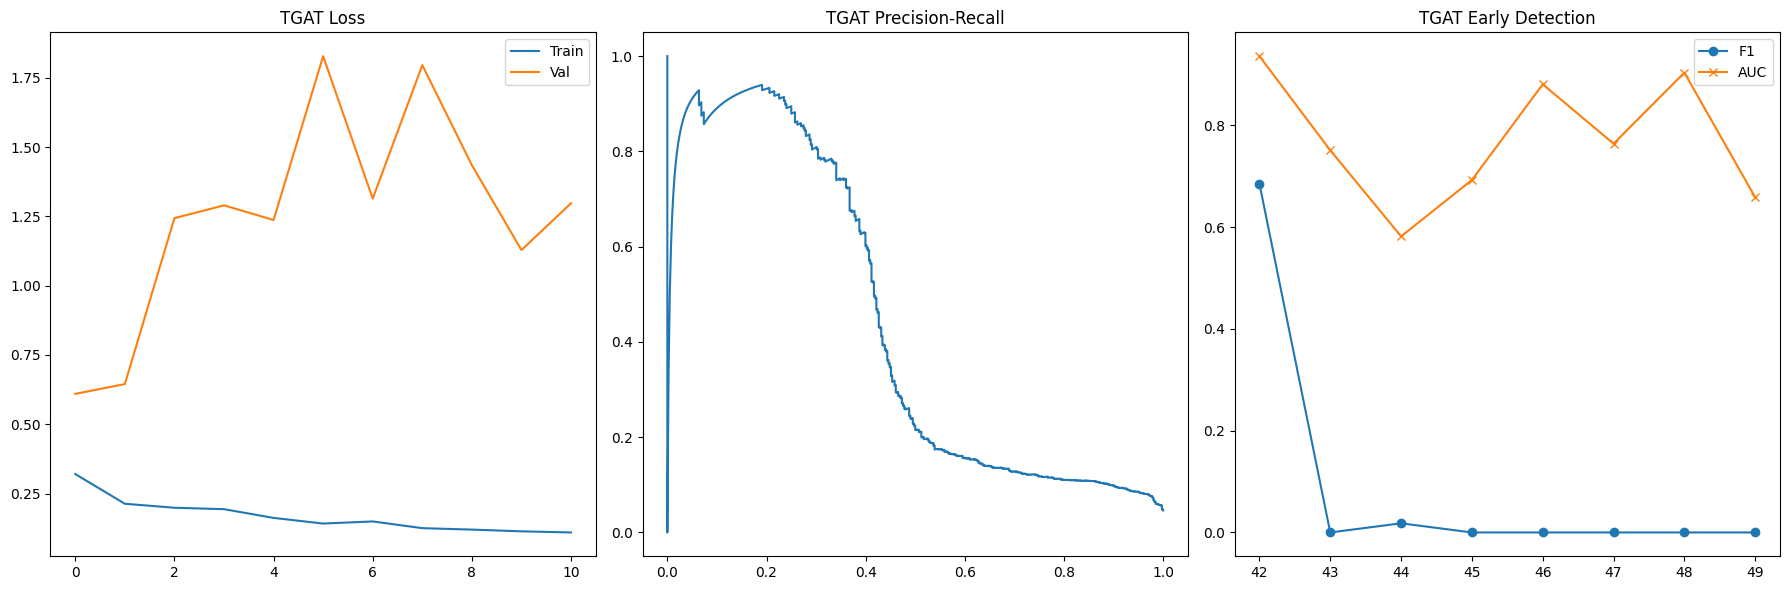

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score
import matplotlib.pyplot as plt
import math

# --- Step 1: Load and Prepare Data (Standard) ---
print("Starting Step 1: Load and Prepare Data...")
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
except FileNotFoundError:
    print("Error: CSV files not found.")
    exit()

feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols

all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

# --- Step 2: Preprocessing ---
print("Starting Step 2: Preprocessing...")
# Drop 'timestep' from X because we will handle it separately via TimeEncoder
features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values # Keep raw timesteps for encoding

train_mask_idx = X_df.index[(timesteps >= 1) & (timesteps <= 34) & (y_series.notna())].values
val_mask_idx = X_df.index[(timesteps >= 35) & (timesteps <= 41) & (y_series.notna())].values
test_mask_idx = X_df.index[(timesteps >= 42) & (timesteps <= 49) & (y_series.notna())].values

scaler = StandardScaler()
X_train_features = X_df.loc[train_mask_idx]
scaler.fit(X_train_features)
X_scaled = scaler.transform(X_df)

# --- Step 3: PyG Data Object ---
print("Starting Step 3: Create Data Object...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.values, dtype=torch.long),
    # Important: We store timestep separately to feed into TimeEncoder
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

data.train_mask = torch.tensor(train_mask_idx, dtype=torch.long)
data.val_mask = torch.tensor(val_mask_idx, dtype=torch.long)
data.test_mask = torch.tensor(test_mask_idx, dtype=torch.long)

# Class Weights
y_train_only = data.y[data.train_mask].cpu().numpy()
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_only), y=y_train_only)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

# DataLoaders
train_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=512, input_nodes=data.train_mask, shuffle=True)
val_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=512, input_nodes=data.val_mask)
test_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=512, input_nodes=data.test_mask)

# --- Step 4: Define TGAT Components ---

class TimeEncoder(nn.Module):
    """
    Functional Time Encoding based on Bochner's Theorem.
    From: Xu et al. 2020
    """
    def __init__(self, out_channels):
        super().__init__()
        self.out_channels = out_channels
        # Trainable frequencies
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
        
    def forward(self, t):
        # t: [batch_size]
        t = t.unsqueeze(-1) # [batch_size, 1]
        # cos(wt + b)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    """
    Custom TGAT Layer.
    Aggregates neighbor features + Time Encodings via Attention.
    """
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.1):
        super().__init__(node_dim=0, aggr='add')
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.time_channels = time_channels
        self.dropout = dropout

        # Dimension per head
        self.head_dim = out_channels // heads
        
        # Linear transformations for Query, Key, Value
        # Input dim = node_features + time_encoding
        total_in_dim = in_channels + time_channels
        
        self.lin_q = nn.Linear(total_in_dim, out_channels)
        self.lin_k = nn.Linear(total_in_dim, out_channels)
        self.lin_v = nn.Linear(total_in_dim, out_channels)
        
        self.lin_skip = nn.Linear(in_channels, out_channels) # Skip connection

        # Attention parameters
        self.att = nn.Parameter(torch.Tensor(1, heads, 2 * self.head_dim))
        nn.init.xavier_uniform_(self.att)

    def forward(self, x, edge_index, t_emb):
        # x: Node features [N, in_channels]
        # t_emb: Time embeddings [N, time_channels]
        
        # Concatenate Node Features + Time Embeddings
        # Z(t) in Eq. 6 of TGAT paper
        x_in = torch.cat([x, t_emb], dim=-1) 
        
        # Compute Q, K, V
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)

        # Propagate
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        
        out = out.view(-1, self.out_channels)
        
        # Skip connection + Residual
        out = out + self.lin_skip(x)
        
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        # Simple Dot Product Attention (Scaled)
        alpha = (q_i * k_j).sum(dim=-1) / math.sqrt(self.head_dim)
        
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        
        return v_j * alpha.unsqueeze(-1)

class TGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=2)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=2)
        
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, edge_index, t):
        # 1. Encode Time
        t_emb = self.time_enc(t)
        
        # 2. TGAT Layer 1
        x = self.conv1(x, edge_index, t_emb)
        x = F.relu(x)
        x = self.dropout(x)
        
        # 3. TGAT Layer 2
        x = self.conv2(x, edge_index, t_emb)
        x = F.relu(x)
        x = self.dropout(x)
        
        # 4. Classifier
        out = self.lin_out(x)
        return F.log_softmax(out, dim=1)

# --- Step 5: Training Setup ---
print("Starting Step 5: Training Setup...")

model = TGATModel(
    num_features=data.num_features,
    hidden_dim=128,
    num_classes=2,
    time_dim=32 # Dimension for time encoding
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005) 
loss_fn = torch.nn.NLLLoss(weight=class_weights)

# --- Step 6: Training Loop ---
print("\nStarting Step 6: Training TGAT...")

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(50):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Pass x, edge_index AND timestep (ts) to the model
        out = model(batch.x, batch.edge_index, batch.ts)
        
        loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_tgat_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# --- Step 7: Evaluation ---
print("\nStarting Step 7: Final Evaluation...")
model.load_state_dict(torch.load('best_tgat_model.pth'))
model.eval()

all_true, all_pred, all_proba, all_ts = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.ts)
        
        target_out = out[:batch.batch_size]
        target_y = batch.y[:batch.batch_size]
        
        target_ts = batch.ts[:batch.batch_size].cpu().numpy()
        
        all_true.append(target_y.cpu().numpy())
        all_pred.append(target_out.argmax(dim=1).cpu().numpy())
        all_proba.append(target_out.exp()[:, 1].cpu().numpy())
        all_ts.append(target_ts)

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)
y_proba = np.concatenate(all_proba)
timesteps_test = np.concatenate(all_ts)

# Metrics
precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)
auc = roc_auc_score(y_true, y_proba)

print("--- PERFORMANCE REPORT (TGAT) ---")
print(f"Precision (Illicit): {precision:.4f}")
print(f"Recall (Illicit):    {recall:.4f}")
print(f"F1-Score (Illicit):  {f1:.4f}")
print(f"ROC AUC:             {auc:.4f}")


print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)']))

# Early Detection Plot
unique_ts = sorted(np.unique(timesteps_test))
f1_time, auc_time = [], []

for t in unique_ts:
    mask = (timesteps_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true[mask])) > 1:
        f1_time.append(f1_score(y_true[mask], y_pred[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true[mask], y_proba[mask]))
    else:
        f1_time.append(0.0)
        auc_time.append(0.5) 

# Plotting
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('TGAT Loss')
plt.legend()

plt.subplot(1, 3, 2)
prec, rec, _ = precision_recall_curve(y_true, y_proba, pos_label=1)
plt.plot(rec, prec)
plt.title('TGAT Precision-Recall')

plt.subplot(1, 3, 3)
plt.plot(unique_ts, f1_time, marker='o', label='F1')
plt.plot(unique_ts, auc_time, marker='x', label='AUC')
plt.title('TGAT Early Detection')
plt.legend()

plt.tight_layout()
plt.savefig('tgat_results.png')
print("Results saved to 'tgat_results.png'")